# Multiverse Analysis: Bill Morphology and Simpson's Paradox

This notebook demonstrates how a multiverse analysis can reveal **Simpson's Paradox** — a phenomenon where a trend appears in pooled data but reverses when the data are stratified by a confounding variable.

## Ecological Context

Bill morphology in penguins is shaped by foraging ecology. Bill depth and length are expected to scale allometrically — larger birds generally have proportionally larger bills. However, the three *Pygoscelis* species occupy different ecological niches:

- **Adélie**: Generalist feeders, intermediate bill dimensions
- **Chinstrap**: Krill specialists, relatively deep bills
- **Gentoo**: Fish and krill feeders, longer but shallower bills

## The Paradox

**Question**: Is bill depth positively correlated with bill length (allometric scaling)?

- **Pooled across species** → Negative correlation
- **Within each species** → Positive correlation

This makes it a compelling multiverse demonstration because the "correct" answer depends entirely on whether you think species should be controlled for — a decision with no objectively right answer.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Load Data

In [2]:
from palmerpenguins import load_penguins

penguins = load_penguins()
print(f"Dataset shape: {penguins.shape}")
print(f"\nSpecies counts:")
print(penguins['species'].value_counts())
penguins.head()

Dataset shape: (344, 8)

Species counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Visualizing Simpson's Paradox

First, let's see the paradox visually before running the multiverse.

Adelie: r = 0.391 (POSITIVE)
Gentoo: r = 0.643 (POSITIVE)
Chinstrap: r = 0.654 (POSITIVE)


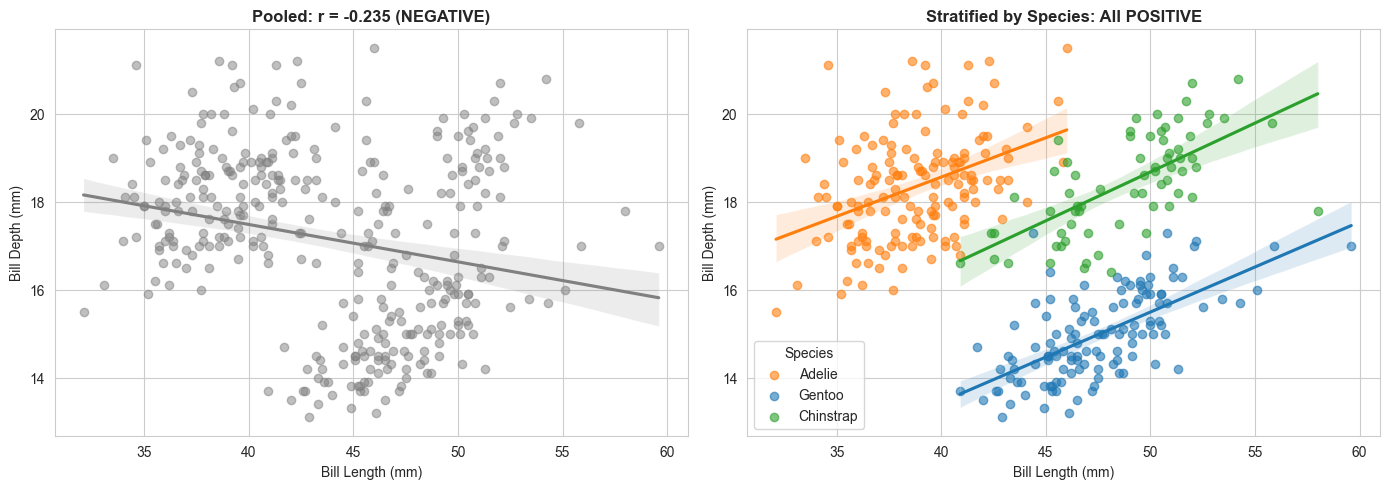


*** SIMPSON'S PARADOX ***
Pooled correlation: r = -0.235 (negative)
Within-species correlations: all positive!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Pooled data (ignoring species)
ax1 = axes[0]
sns.regplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', 
            ax=ax1, scatter_kws={'alpha': 0.5}, color='gray')
r_pooled, p_pooled = stats.pearsonr(
    penguins['bill_length_mm'].dropna(), 
    penguins.loc[penguins['bill_length_mm'].notna(), 'bill_depth_mm'].dropna()
)
ax1.set_title(f'Pooled: r = {r_pooled:.3f} (NEGATIVE)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Bill Length (mm)')
ax1.set_ylabel('Bill Depth (mm)')

# Right: Stratified by species
ax2 = axes[1]
colors = {'Adelie': '#ff7f0e', 'Chinstrap': '#2ca02c', 'Gentoo': '#1f77b4'}
for species in penguins['species'].unique():
    subset = penguins[penguins['species'] == species].dropna(subset=['bill_length_mm', 'bill_depth_mm'])
    sns.regplot(data=subset, x='bill_length_mm', y='bill_depth_mm',
                ax=ax2, scatter_kws={'alpha': 0.6}, color=colors[species], label=species)
    r, _ = stats.pearsonr(subset['bill_length_mm'], subset['bill_depth_mm'])
    print(f"{species}: r = {r:.3f} (POSITIVE)")

ax2.set_title('Stratified by Species: All POSITIVE', fontsize=12, fontweight='bold')
ax2.set_xlabel('Bill Length (mm)')
ax2.set_ylabel('Bill Depth (mm)')
ax2.legend(title='Species')

plt.tight_layout()
plt.savefig('simpsons_paradox_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n*** SIMPSON'S PARADOX ***")
print(f"Pooled correlation: r = {r_pooled:.3f} (negative)")
print(f"Within-species correlations: all positive!")

## Define the Multiverse

The key question: **Should we control for species?**

Arguments for pooling (ignoring species):
- We're interested in the general relationship across penguins
- Species differences are part of the natural variation

Arguments for stratifying/controlling:
- Species is a confound — each species has different bill morphology
- Within-species variation reflects true allometric scaling

We'll explore multiple analytical decisions:

| Decision | Options | Rationale |
|----------|---------|----------|
| **Species handling** | pooled, covariate, interaction, separate | How to account for species |
| **Sex adjustment** | ignore, covariate | Sexual dimorphism may confound |
| **Island adjustment** | ignore, covariate | Geographic variation |
| **Model type** | correlation, regression | Correlation vs. slope estimate |
| **Standardization** | raw, z-scored | Scale of variables |

In [4]:
# Define all forking paths
FORKING_PATHS = {
    'species_handling': ['pooled', 'covariate', 'interaction', 'separate_adelie', 'separate_chinstrap', 'separate_gentoo'],
    'adjust_sex': [False, True],
    'adjust_island': [False, True],
    'standardize': [False, True]
}

# Calculate total specifications
n_specs = np.prod([len(v) for v in FORKING_PATHS.values()])
print(f"Total number of specifications: {n_specs}")

Total number of specifications: 48


## Build Analysis Functions

In [5]:
def prepare_data(df, standardize=False, species_filter=None):
    """Prepare dataset with optional standardization and species filtering."""
    cols_needed = ['bill_length_mm', 'bill_depth_mm', 'species', 'sex', 'island']
    data = df[cols_needed].dropna().copy()
    
    # Filter to single species if requested
    if species_filter:
        data = data[data['species'] == species_filter].copy()
    
    # Standardize continuous variables
    if standardize:
        data['bill_length_mm'] = (data['bill_length_mm'] - data['bill_length_mm'].mean()) / data['bill_length_mm'].std()
        data['bill_depth_mm'] = (data['bill_depth_mm'] - data['bill_depth_mm'].mean()) / data['bill_depth_mm'].std()
    
    return data


def run_single_specification(df, species_handling, adjust_sex, adjust_island, standardize):
    """Run a single analysis specification and return results."""
    
    # Handle separate species analyses
    species_filter = None
    if species_handling.startswith('separate_'):
        species_filter = species_handling.replace('separate_', '').capitalize()
        species_handling_model = 'pooled'  # No species term needed
    else:
        species_handling_model = species_handling
    
    data = prepare_data(df, standardize=standardize, species_filter=species_filter)
    
    if len(data) < 10:
        return None
    
    # Build formula
    predictors = ['bill_length_mm']
    
    if species_handling_model == 'covariate':
        predictors.append('species')
    elif species_handling_model == 'interaction':
        predictors.append('species')
        predictors.append('bill_length_mm:species')
    
    if adjust_sex:
        predictors.append('sex')
    
    if adjust_island and species_filter is None:  # Island only makes sense with multiple species
        predictors.append('island')
    
    formula = f"bill_depth_mm ~ {' + '.join(predictors)}"
    
    try:
        model = smf.ols(formula, data=data).fit()
        
        # Extract bill_length coefficient
        coef = model.params.get('bill_length_mm', np.nan)
        se = model.bse.get('bill_length_mm', np.nan)
        pval = model.pvalues.get('bill_length_mm', np.nan)
        
        # Also compute simple correlation for comparison
        r, r_pval = stats.pearsonr(data['bill_length_mm'], data['bill_depth_mm'])
        
        # Partial correlation (controlling for other variables)
        if len(predictors) > 1:
            # Residualize both variables
            other_predictors = [p for p in predictors if p != 'bill_length_mm' and ':' not in p]
            if other_predictors:
                formula_x = f"bill_length_mm ~ {' + '.join(other_predictors)}"
                formula_y = f"bill_depth_mm ~ {' + '.join(other_predictors)}"
                try:
                    resid_x = smf.ols(formula_x, data=data).fit().resid
                    resid_y = smf.ols(formula_y, data=data).fit().resid
                    partial_r, _ = stats.pearsonr(resid_x, resid_y)
                except:
                    partial_r = r
            else:
                partial_r = r
        else:
            partial_r = r
        
        return {
            'species_handling': species_handling,
            'adjust_sex': adjust_sex,
            'adjust_island': adjust_island,
            'standardize': standardize,
            'n': len(data),
            'coefficient': coef,
            'std_error': se,
            'p_value': pval,
            'simple_r': r,
            'partial_r': partial_r,
            'r_squared': model.rsquared,
            'formula': formula,
            'direction': 'positive' if coef > 0 else 'negative'
        }
    except Exception as e:
        print(f"Error: {e}")
        return None

## Run the Multiverse

In [6]:
def run_multiverse(df, forking_paths):
    """Run all specifications in the multiverse."""
    results = []
    
    # Generate all combinations
    keys = list(forking_paths.keys())
    combinations = list(product(*[forking_paths[k] for k in keys]))
    
    for combo in combinations:
        spec = dict(zip(keys, combo))
        result = run_single_specification(
            df,
            species_handling=spec['species_handling'],
            adjust_sex=spec['adjust_sex'],
            adjust_island=spec['adjust_island'],
            standardize=spec['standardize']
        )
        if result is not None:
            results.append(result)
    
    return pd.DataFrame(results)


# Run the multiverse
multiverse_results = run_multiverse(penguins, FORKING_PATHS)
print(f"Completed {len(multiverse_results)} specifications")
multiverse_results.head(10)

Completed 48 specifications


,species_handling,adjust_sex,adjust_island,standardize,n,coefficient,std_error,p_value,simple_r,partial_r,r_squared,formula,direction
0,pooled,False,False,False,333,-0.082327,0.019268,2.528290e-05,-0.228626,-0.228626,0.052270,bill_depth_mm ~ bill_length_mm,negative
1,pooled,False,False,True,333,-0.228626,0.053509,2.528290e-05,-0.228626,-0.228626,0.052270,bill_depth_mm ~ bill_length_mm,negative
2,pooled,False,True,False,333,-0.034499,0.016604,3.850311e-02,-0.228626,-0.113808,0.400359,bill_depth_mm ~ bill_length_mm + island,negative
3,pooled,False,True,True,333,-0.095806,0.046109,3.850311e-02,-0.228626,-0.113808,0.400359,bill_depth_mm ~ bill_length_mm + island,negative
4,pooled,True,False,False,333,-0.145757,0.017872,7.349545e-15,-0.228626,-0.409564,0.283331,bill_depth_mm ~ bill_length_mm + sex,negative
5,pooled,True,False,True,333,-0.404775,0.049632,7.349545e-15,-0.228626,-0.409564,0.283331,bill_depth_mm ~ bill_length_mm + sex,negative
6,pooled,True,True,False,333,-0.102154,0.014677,1.854607e-11,-0.228626,-0.358742,0.595590,bill_depth_mm ~ bill_length_mm + sex + island,negative
7,pooled,True,True,True,333,-0.283688,0.040757,1.854607e-11,-0.228626,-0.358742,0.595590,bill_depth_mm ~ bill_length_mm + sex + island,negative
8,covariate,False,False,False,333,0.200443,0.017680,2.258955e-25,-0.228626,0.530032,0.767281,bill_depth_mm ~ bill_length_mm + species,positive
9,covariate,False,False,True,333,0.556641,0.049098,2.258955e-25,-0.228626,0.530032,0.767281,bill_depth_mm ~ bill_length_mm + species,positive


## The Key Result: Direction Reversal

Let's see how many specifications show positive vs. negative relationships.

In [7]:
# Count directions
direction_counts = multiverse_results['direction'].value_counts()
print("Direction of bill_length → bill_depth relationship:")
print("=" * 50)
print(direction_counts)
print(f"\nPositive: {direction_counts.get('positive', 0)} specifications")
print(f"Negative: {direction_counts.get('negative', 0)} specifications")

# Which specifications are negative?
print("\n" + "=" * 50)
print("Specifications with NEGATIVE relationship:")
print("=" * 50)
negative_specs = multiverse_results[multiverse_results['direction'] == 'negative']
print(negative_specs[['species_handling', 'adjust_sex', 'adjust_island', 'coefficient', 'p_value']])

Direction of bill_length → bill_depth relationship:
direction
positive    40
negative     8
Name: count, dtype: int64

Positive: 40 specifications
Negative: 8 specifications

Specifications with NEGATIVE relationship:
  species_handling  adjust_sex  adjust_island  coefficient       p_value
0           pooled       False          False    -0.082327  2.528290e-05
1           pooled       False          False    -0.228626  2.528290e-05
2           pooled       False           True    -0.034499  3.850311e-02
3           pooled       False           True    -0.095806  3.850311e-02
4           pooled        True          False    -0.145757  7.349545e-15
5           pooled        True          False    -0.404775  7.349545e-15
6           pooled        True           True    -0.102154  1.854607e-11
7           pooled        True           True    -0.283688  1.854607e-11


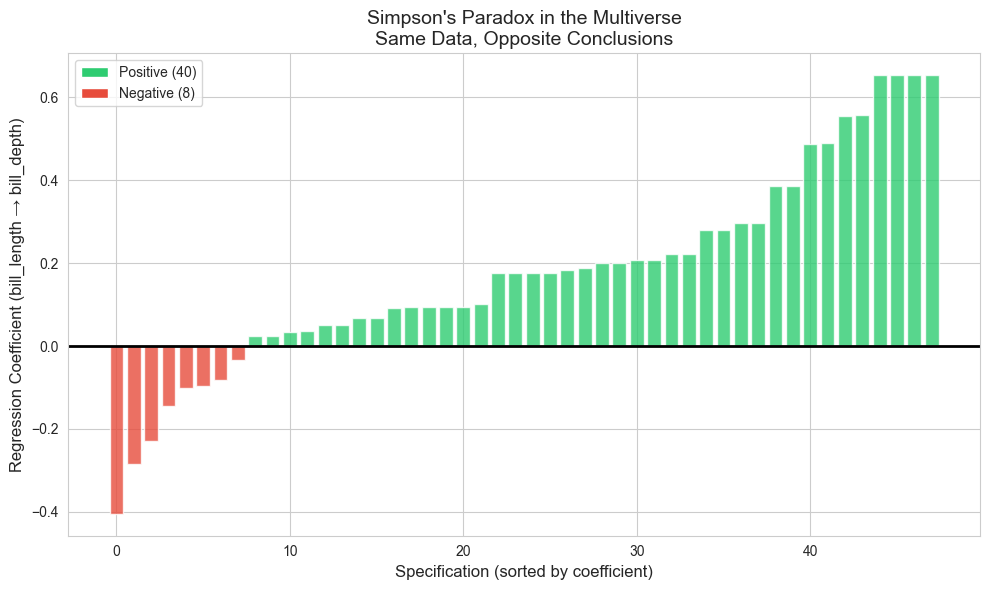

In [8]:
# Visualize the split
fig, ax = plt.subplots(figsize=(10, 6))

# Color by direction
colors = multiverse_results['direction'].map({'positive': '#2ecc71', 'negative': '#e74c3c'})

# Sort by coefficient
sorted_results = multiverse_results.sort_values('coefficient').reset_index(drop=True)
sorted_colors = sorted_results['direction'].map({'positive': '#2ecc71', 'negative': '#e74c3c'})

ax.bar(range(len(sorted_results)), sorted_results['coefficient'], color=sorted_colors, alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax.set_xlabel('Specification (sorted by coefficient)', fontsize=12)
ax.set_ylabel('Regression Coefficient (bill_length → bill_depth)', fontsize=12)
ax.set_title('Simpson\'s Paradox in the Multiverse\nSame Data, Opposite Conclusions', fontsize=14)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label=f'Positive ({(sorted_results["direction"]=="positive").sum()})'),
    Patch(facecolor='#e74c3c', label=f'Negative ({(sorted_results["direction"]=="negative").sum()})')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('multiverse_direction_reversal.png', dpi=150, bbox_inches='tight')
plt.show()

## Specification Curve

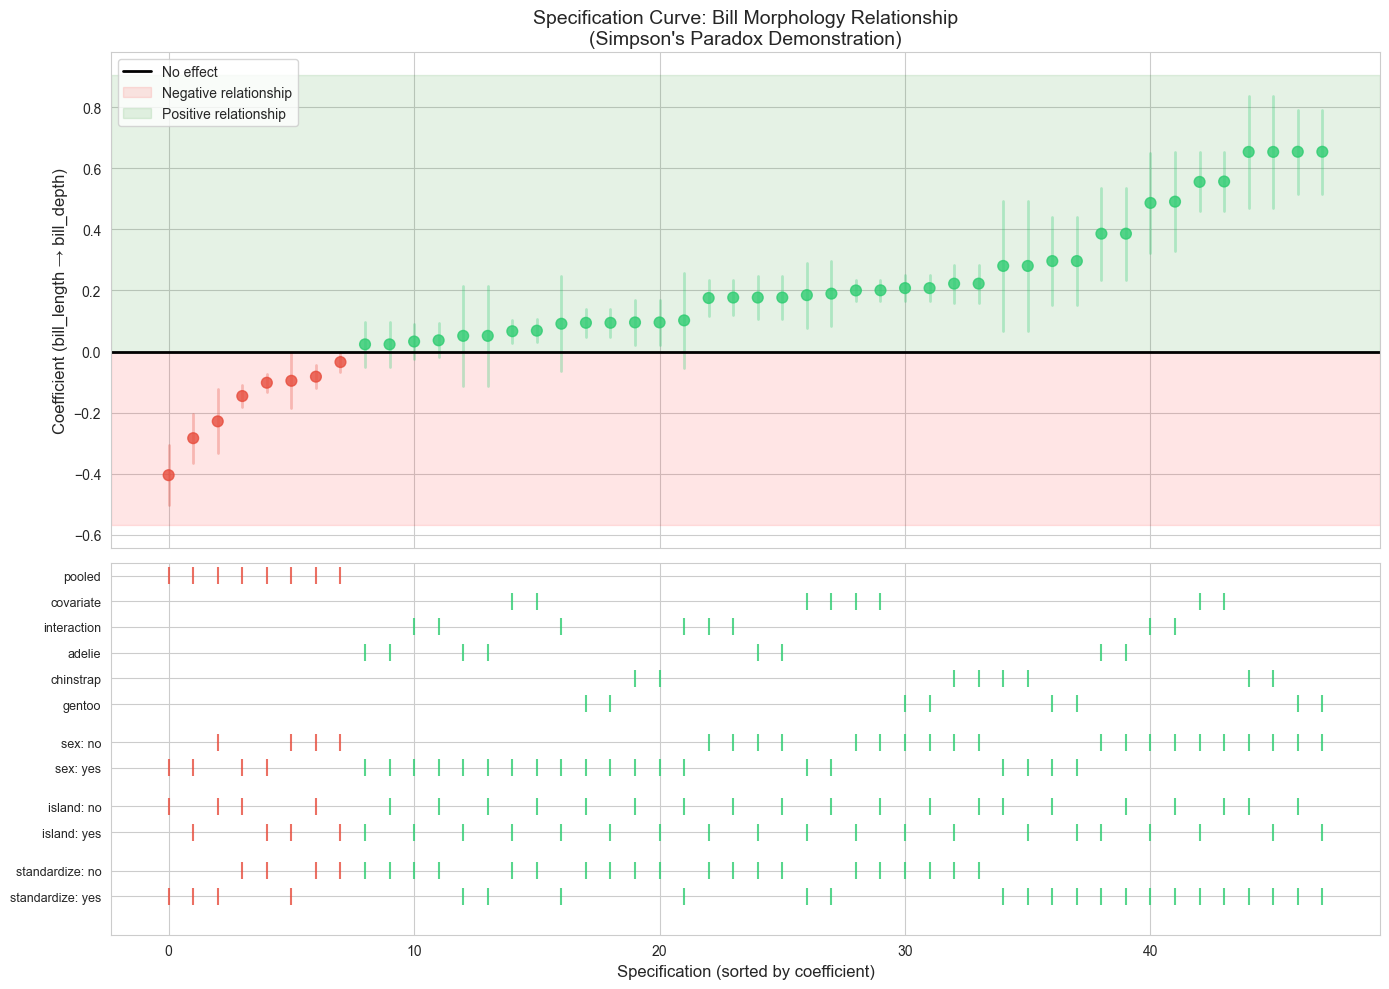

In [9]:
def plot_specification_curve_simpsons(results):
    """Create a specification curve plot highlighting Simpson's Paradox."""
    # Sort by coefficient
    df = results.sort_values('coefficient').reset_index(drop=True)
    df['spec_number'] = range(len(df))
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), 
                             gridspec_kw={'height_ratios': [2, 1.5]},
                             sharex=True)
    
    # Top panel: Coefficients with confidence intervals
    ax1 = axes[0]
    colors = df['direction'].map({'positive': '#2ecc71', 'negative': '#e74c3c'})
    
    # Plot points
    ax1.scatter(df['spec_number'], df['coefficient'], c=colors, s=60, alpha=0.8, zorder=3)
    
    # Error bars
    for idx, row in df.iterrows():
        color = '#2ecc71' if row['direction'] == 'positive' else '#e74c3c'
        ax1.plot([row['spec_number'], row['spec_number']], 
                 [row['coefficient'] - 1.96*row['std_error'], 
                  row['coefficient'] + 1.96*row['std_error']], 
                 color=color, alpha=0.3, linewidth=2)
    
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=2, label='No effect')
    ax1.set_ylabel('Coefficient (bill_length → bill_depth)', fontsize=12)
    ax1.set_title('Specification Curve: Bill Morphology Relationship\n(Simpson\'s Paradox Demonstration)', fontsize=14)
    
    # Shade regions
    ax1.axhspan(ax1.get_ylim()[0], 0, alpha=0.1, color='red', label='Negative relationship')
    ax1.axhspan(0, ax1.get_ylim()[1], alpha=0.1, color='green', label='Positive relationship')
    ax1.legend(loc='upper left')
    
    # Bottom panel: Specification indicators
    ax2 = axes[1]
    
    decisions = [
        ('species_handling', ['pooled', 'covariate', 'interaction', 
                              'separate_adelie', 'separate_chinstrap', 'separate_gentoo']),
        ('adjust_sex', [False, True]),
        ('adjust_island', [False, True]),
        ('standardize', [False, True])
    ]
    
    y_positions = []
    y_labels = []
    y_pos = 0
    
    for decision_name, options in decisions:
        for option in options:
            mask = df[decision_name] == option
            x_vals = df.loc[mask, 'spec_number']
            point_colors = df.loc[mask, 'direction'].map({'positive': '#2ecc71', 'negative': '#e74c3c'})
            ax2.scatter(x_vals, [y_pos] * len(x_vals), marker='|', s=150, 
                       c=point_colors, alpha=0.8)
            y_positions.append(y_pos)
            
            # Clean up label
            if isinstance(option, bool):
                label = f"{decision_name.replace('adjust_', '').replace('_', ' ')}: {'yes' if option else 'no'}"
            else:
                label = str(option).replace('_', ' ').replace('separate ', '')
            y_labels.append(label)
            y_pos += 1
        y_pos += 0.5
    
    ax2.set_yticks(y_positions)
    ax2.set_yticklabels(y_labels, fontsize=9)
    ax2.set_xlabel('Specification (sorted by coefficient)', fontsize=12)
    ax2.set_ylim(-0.5, y_pos)
    ax2.invert_yaxis()
    
    plt.tight_layout()
    return fig


fig = plot_specification_curve_simpsons(multiverse_results)
plt.savefig('specification_curve_simpsons.png', dpi=150, bbox_inches='tight')
plt.show()

## What Drives the Direction Reversal?

In [10]:
# Analyze what predicts direction
print("Coefficient by Species Handling:")
print("=" * 60)
summary_by_species = multiverse_results.groupby('species_handling').agg({
    'coefficient': ['mean', 'std', 'min', 'max'],
    'direction': lambda x: (x == 'positive').mean()
}).round(3)
summary_by_species.columns = ['mean_coef', 'std_coef', 'min_coef', 'max_coef', 'pct_positive']
print(summary_by_species.sort_values('mean_coef'))

Coefficient by Species Handling:
                    mean_coef  std_coef  min_coef  max_coef  pct_positive
species_handling                                                         
pooled                 -0.172     0.124    -0.405    -0.034           0.0
separate_adelie         0.159     0.153     0.024     0.386           1.0
interaction             0.199     0.187     0.033     0.491           1.0
covariate               0.253     0.195     0.066     0.557           1.0
separate_chinstrap      0.313     0.222     0.095     0.654           1.0
separate_gentoo         0.313     0.224     0.094     0.654           1.0


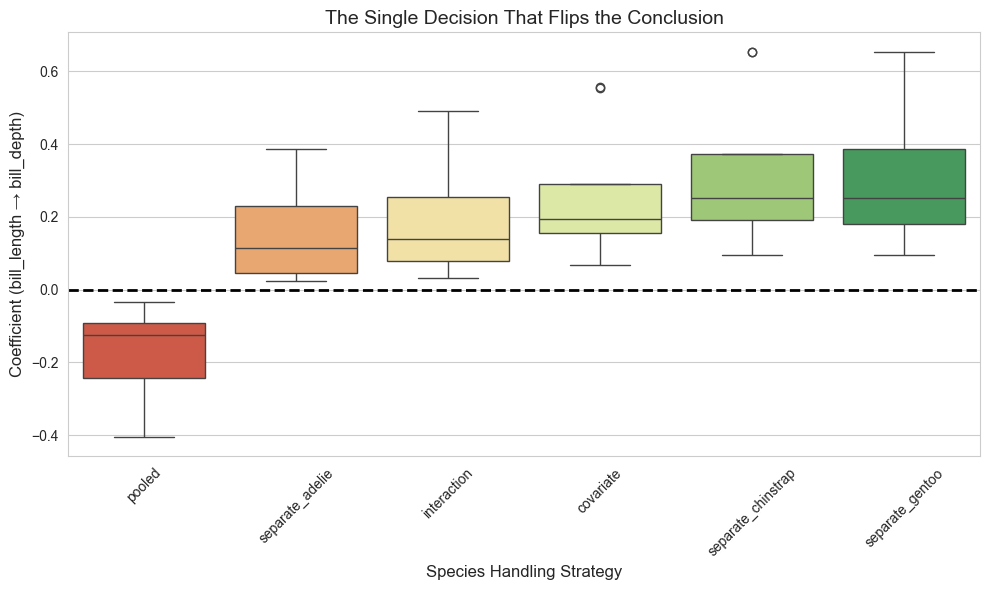

In [11]:
# Visualize the key driver
fig, ax = plt.subplots(figsize=(10, 6))

# Order species handling by mean coefficient
order = multiverse_results.groupby('species_handling')['coefficient'].mean().sort_values().index

sns.boxplot(data=multiverse_results, x='species_handling', y='coefficient', 
            order=order, ax=ax, palette='RdYlGn')
ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax.set_xlabel('Species Handling Strategy', fontsize=12)
ax.set_ylabel('Coefficient (bill_length → bill_depth)', fontsize=12)
ax.set_title('The Single Decision That Flips the Conclusion', fontsize=14)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('key_driver_simpsons.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics

In [12]:
def summarize_simpsons_multiverse(results):
    """Generate summary statistics highlighting Simpson's Paradox."""
    n_positive = (results['direction'] == 'positive').sum()
    n_negative = (results['direction'] == 'negative').sum()
    
    summary = {
        'Total specifications': len(results),
        'Positive relationships': n_positive,
        'Negative relationships': n_negative,
        'Percent positive': f"{n_positive / len(results) * 100:.1f}%",
        'Percent negative': f"{n_negative / len(results) * 100:.1f}%",
        'Coefficient range': f"{results['coefficient'].min():.3f} to {results['coefficient'].max():.3f}",
        'All significant (p<0.05)': f"{(results['p_value'] < 0.05).sum()}/{len(results)}",
    }
    
    # Key insight
    pooled_coef = results[results['species_handling'] == 'pooled']['coefficient'].mean()
    controlled_coef = results[results['species_handling'].isin(['covariate', 'interaction', 
                                                                 'separate_adelie', 'separate_chinstrap', 
                                                                 'separate_gentoo'])]['coefficient'].mean()
    
    summary['Mean coef (pooled)'] = f"{pooled_coef:.3f}"
    summary['Mean coef (species-controlled)'] = f"{controlled_coef:.3f}"
    
    return summary


summary = summarize_simpsons_multiverse(multiverse_results)
print("=" * 60)
print("MULTIVERSE SUMMARY: SIMPSON'S PARADOX")
print("=" * 60)
for key, value in summary.items():
    print(f"{key:35s}: {value}")

MULTIVERSE SUMMARY: SIMPSON'S PARADOX
Total specifications               : 48
Positive relationships             : 40
Negative relationships             : 8
Percent positive                   : 83.3%
Percent negative                   : 16.7%
Coefficient range                  : -0.405 to 0.654
All significant (p<0.05)           : 40/48
Mean coef (pooled)                 : -0.172
Mean coef (species-controlled)     : 0.247


## Detailed Comparison: Pooled vs. Controlled

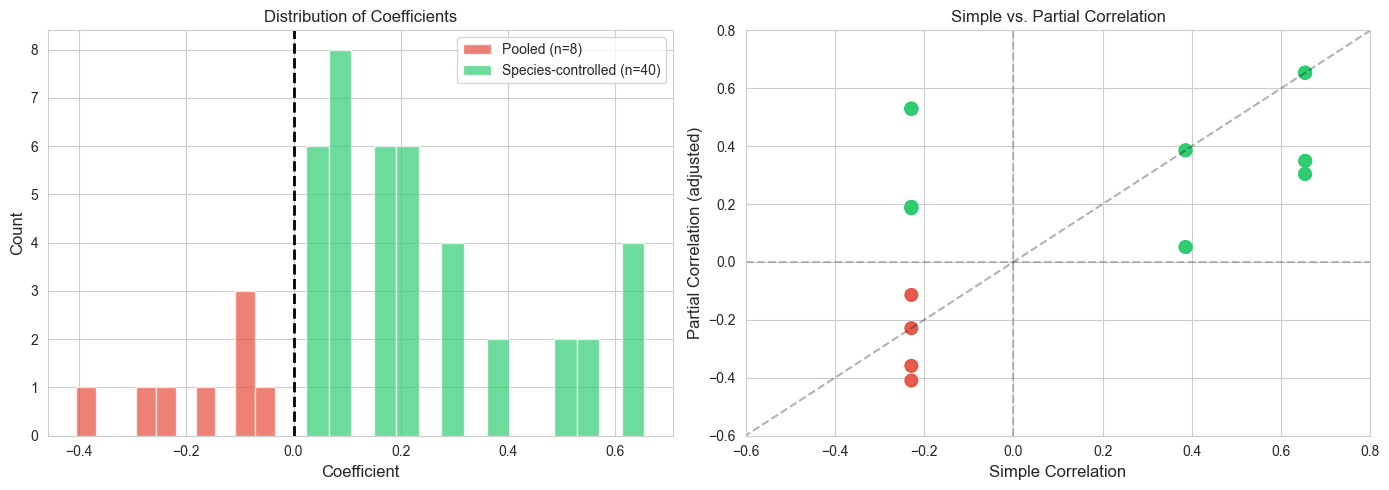

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of coefficients
ax1 = axes[0]
pooled = multiverse_results[multiverse_results['species_handling'] == 'pooled']['coefficient']
controlled = multiverse_results[multiverse_results['species_handling'] != 'pooled']['coefficient']

ax1.hist(pooled, bins=10, alpha=0.7, label=f'Pooled (n={len(pooled)})', color='#e74c3c')
ax1.hist(controlled, bins=15, alpha=0.7, label=f'Species-controlled (n={len(controlled)})', color='#2ecc71')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax1.set_xlabel('Coefficient', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Coefficients', fontsize=12)
ax1.legend()

# Correlation comparison
ax2 = axes[1]
ax2.scatter(multiverse_results['simple_r'], multiverse_results['partial_r'], 
            c=multiverse_results['direction'].map({'positive': '#2ecc71', 'negative': '#e74c3c'}),
            alpha=0.7, s=80)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.plot([-1, 1], [-1, 1], 'k--', alpha=0.3, label='x=y')
ax2.set_xlabel('Simple Correlation', fontsize=12)
ax2.set_ylabel('Partial Correlation (adjusted)', fontsize=12)
ax2.set_title('Simple vs. Partial Correlation', fontsize=12)
ax2.set_xlim(-0.6, 0.8)
ax2.set_ylim(-0.6, 0.8)

plt.tight_layout()
plt.savefig('pooled_vs_controlled.png', dpi=150, bbox_inches='tight')
plt.show()

## Full Results Table

In [14]:
# Display all specifications
display_cols = ['species_handling', 'adjust_sex', 'adjust_island', 'standardize',
                'coefficient', 'p_value', 'simple_r', 'partial_r', 'direction', 'n']

results_display = multiverse_results[display_cols].copy()
results_display = results_display.sort_values('coefficient')
results_display['coefficient'] = results_display['coefficient'].round(4)
results_display['p_value'] = results_display['p_value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
results_display['simple_r'] = results_display['simple_r'].round(3)
results_display['partial_r'] = results_display['partial_r'].round(3)

print("All specifications (sorted by coefficient):")
results_display

All specifications (sorted by coefficient):


,species_handling,adjust_sex,adjust_island,standardize,coefficient,p_value,simple_r,partial_r,direction,n
5,pooled,True,False,True,-0.4048,7.35e-15,-0.229,-0.410,negative,333
7,pooled,True,True,True,-0.2837,1.85e-11,-0.229,-0.359,negative,333
1,pooled,False,False,True,-0.2286,2.53e-05,-0.229,-0.229,negative,333
4,pooled,True,False,False,-0.1458,7.35e-15,-0.229,-0.410,negative,333
6,pooled,True,True,False,-0.1022,1.85e-11,-0.229,-0.359,negative,333
3,pooled,False,True,True,-0.0958,0.0385,-0.229,-0.114,negative,333
0,pooled,False,False,False,-0.0823,2.53e-05,-0.229,-0.229,negative,333
2,pooled,False,True,False,-0.0345,0.0385,-0.229,-0.114,negative,333
30,separate_adelie,True,True,False,0.0235,0.5374,0.386,0.052,positive,146
28,separate_adelie,True,False,False,0.0235,0.5374,0.386,0.052,positive,146


## Conclusions

### Simpson's Paradox Demonstrated

This multiverse analysis reveals a striking example of **Simpson's Paradox**:

1. **Pooled analysis**: Bill length and depth are **negatively** correlated (r ≈ -0.24)
2. **Within-species analysis**: Bill length and depth are **positively** correlated (r ≈ 0.4-0.6)

### The Key Decision

The **species handling** decision completely determines the direction of the result:
- Ignore species → Negative relationship
- Control for species → Positive relationship

### Why This Happens

Gentoo penguins have **long but shallow** bills, while Adélie and Chinstrap have **shorter but deeper** bills. When you pool the data, you're mixing between-species variation (negative) with within-species variation (positive).

### Implications

1. **No objectively correct answer**: Both analyses are valid depending on your research question:
   - "How does bill morphology vary across penguins?" → Pool
   - "Does allometric scaling hold within species?" → Stratify

2. **Transparency matters**: A single reported result hides this fundamental ambiguity

3. **Multiverse as discovery**: The multiverse doesn't just show robustness — it reveals hidden structure in the data

In [15]:
# Save results
multiverse_results.to_csv('multiverse_simpsons_paradox.csv', index=False)
print("Results saved to multiverse_simpsons_paradox.csv")

Results saved to multiverse_simpsons_paradox.csv
